<a href="https://colab.research.google.com/github/pdrdias/OpenLab-Projects/blob/main/Emiss%C3%A3o_CO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Carbon_(CO2)_Emissions_by_Country.csv',sep = ',')
dados

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17
...,...,...,...,...,...
5672,Zimbabwe,Africa,01-01-2004,9770.0,0.80
5673,Zimbabwe,Africa,01-01-2007,9760.0,0.78
5674,Zimbabwe,Africa,01-01-2010,9600.0,0.75
5675,Zimbabwe,Africa,01-01-2009,7750.0,0.61


In [ ]:
dados['Country'].value_counts(dropna = False)

,count
Country,
Afghanistan,30
Albania,30
Algeria,30
Andorra,30
Angola,30
...,...
Micronesia,28
Marshall Islands,28
Mali,28


In [ ]:
dados['Region'].value_counts(dropna = False)

,count
Region,
Africa,1585
Asia,1398
Europe,1230
Americas,1050
Oceania,414


In [ ]:
CO2_global_mean = np.mean(dados['Kilotons of Co2'])
CO2_per_capita_global_mean = np.mean(dados['Metric Tons Per Capita'])
print(f'A média de emissão de CO2 é de {CO2_global_mean} ton')
print(f'A média de emissão de CO2 por capita é de {CO2_per_capita_global_mean} ton / hab')
np.median(dados['Metric Tons Per Capita'])

A média de emissão de CO2 é de 141229.16497445834 ton
A média de emissão de CO2 por capita é de 4.325504667958429 ton / hab


np.float64(2.36)

In [ ]:
dados['Metric Tons Per Capita'].describe()

,Metric Tons Per Capita
count,5677.000000
mean,4.325505
std,5.503834
min,0.000000
25%,0.570000
50%,2.360000
75%,6.340000
max,47.650000


In [ ]:
dados['Metric Tons Per Capita'].value_counts()

,count
Metric Tons Per Capita,
0.06,82
0.05,71
0.07,66
0.04,53
0.08,49
...,...
6.18,1
15.56,1
19.26,1


In [ ]:
#Criação de coluna de classificação:
#Primeiro dois quartis = Baixa emissão
#Entre o segundo quartil e a média = Emissão aceitável
#Entre a média e o tercero quartil = Controlar emissão
#Quarto quartil = Reduzir emissão
Q1 = dados['Metric Tons Per Capita'].quantile(0.25)
Q2 = dados['Metric Tons Per Capita'].quantile(0.5)
Q3 = dados['Metric Tons Per Capita'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = CO2_per_capita_global_mean + 1.5 * IQR #limite superior do gráfico boxplot
limite_inf = CO2_per_capita_global_mean - 1.5 * IQR #limite inferior do gráfico boxplot
print(Q3)
print(CO2_per_capita_global_mean)

6.34
4.325504667958429


In [ ]:
def pais_poluidor (emissao):
  if emissao <= Q2:
    return 'Baixa emissão'
  elif Q2 < emissao <= CO2_per_capita_global_mean:
    return 'Emissão aceitável'
  elif CO2_per_capita_global_mean < emissao <= Q3:
    return 'Controlar emissão'
  elif Q3 < emissao <= limite_sup:
    return 'Emissão elevada'
  else:
    return 'Emissão excessiva. Requer ação imediata!'

In [ ]:
dados['Emissao'] = dados.apply(lambda x: pais_poluidor(x['Metric Tons Per Capita']),axis=1)

In [ ]:
dados['Emissao'].value_counts()

,count
Emissao,
Baixa emissão,2841
Emissão elevada,1074
Emissão aceitável,813
Controlar emissão,605
Emissão excessiva. Requer ação imediata!,344


In [ ]:
dados.groupby('Country')['Emissao'].unique()

,Emissao
Country,
Afghanistan,[Baixa emissão]
Albania,[Baixa emissão]
Algeria,[Emissão aceitável]
Andorra,[Emissão elevada]
Angola,[Baixa emissão]
...,...
Venezuela,"[Controlar emissão, Emissão aceitável]"
Vietnam,"[Emissão aceitável, Baixa emissão]"
Yemen,[Baixa emissão]


In [ ]:
dados.groupby('Emissao')['Country'].unique()

,Country
Emissao,
Baixa emissão,"[Afghanistan, Albania, Angola, Armenia, Bangla..."
Controlar emissão,"[Antigua And Barbuda, Argentina, Armenia, Azer..."
Emissão aceitável,"[Algeria, Antigua And Barbuda, Argentina, Arme..."
Emissão elevada,"[Andorra, Antigua And Barbuda, Austria, Azerba..."
Emissão excessiva. Requer ação imediata!,"[Antigua And Barbuda, Australia, Bahamas, Bahr..."


In [ ]:
dados

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita,Emissao
0,Afghanistan,Asia,01-01-2011,8930.0,0.31,Baixa emissão
1,Afghanistan,Asia,01-01-2012,8080.0,0.27,Baixa emissão
2,Afghanistan,Asia,01-01-2010,7110.0,0.25,Baixa emissão
3,Afghanistan,Asia,01-01-2019,6080.0,0.16,Baixa emissão
4,Afghanistan,Asia,01-01-2018,6070.0,0.17,Baixa emissão
...,...,...,...,...,...,...
5672,Zimbabwe,Africa,01-01-2004,9770.0,0.80,Baixa emissão
5673,Zimbabwe,Africa,01-01-2007,9760.0,0.78,Baixa emissão
5674,Zimbabwe,Africa,01-01-2010,9600.0,0.75,Baixa emissão
5675,Zimbabwe,Africa,01-01-2009,7750.0,0.61,Baixa emissão


In [ ]:
dados[dados['Country']=='Antigua And Barbuda'].value_counts()

Country              Region    Date        Kilotons of Co2  Metric Tons Per Capita  Emissao                                 
Antigua And Barbuda  Americas  01-01-1990  210.0            3.32                    Emissão aceitável                           1
                               01-01-1991  220.0            3.46                    Emissão aceitável                           1
                               01-01-1992  290.0            4.49                    Controlar emissão                           1
                               01-01-1993  250.0            3.80                    Emissão aceitável                           1
                               01-01-1994  250.0            3.73                    Emissão aceitável                           1
                               01-01-1995  270.0            3.95                    Emissão aceitável                           1
                               01-01-1996  280.0            4.01                    Emissão aceitável                           1
                               01-01-1997  290.0            4.07                    Emissão aceitável                           1
                               01-01-1998  320.0            4.41                    Controlar emissão                           1
                               01-01-1999  330.0            4.47                    Controlar emissão                           1
                               01-01-2000  330.0            4.40                    Controlar emissão                           1
                               01-01-2001  350.0            4.59                    Controlar emissão                           1
                               01-01-2002  390.0            5.05                    Controlar emissão                           1
                               01-01-2003  410.0            5.25                    Controlar emissão                           1
                               01-01-2004  400.0            5.07                    Controlar emissão                           1
                               01-01-2005  410.0            5.13                    Controlar emissão                           1
                               01-01-2006  440.0            5.44                    Controlar emissão                           1
                               01-01-2007  460.0            5.61                    Controlar emissão                           1
                               01-01-2008  480.0            5.77                    Controlar emissão                           1
                               01-01-2009  1390.0           16.44                   Emissão excessiva. Requer ação imediata!    1
                               01-01-2010  490.0            5.72                    Controlar emissão                           1
                               01-01-2011  540.0            6.23                    Controlar emissão                           1
                               01-01-2012  700.0            7.98                    Emissão elevada                             1
                               01-01-2013  470.0            5.31                    Controlar emissão                           1
                               01-01-2014  480.0            5.38                    Controlar emissão                           1
                               01-01-2015  490.0            5.45                    Controlar emissão                           1
                               01-01-2016  500.0            5.52                    Controlar emissão                           1
                               01-01-2017  500.0            5.49                    Controlar emissão                           1
                               01-01-2018  510.0            5.57                    Controlar emissão                           1
                               01-01-2019  520.0            5.65                    Controlar emissão    

In [ ]:
def ano_de_contagem(data):
  return data[-4:]

In [ ]:
dados['Year'] = dados['Date'].apply(ano_de_contagem)

In [ ]:
dados['Year']

,Year
0,2011
1,2012
2,2010
3,2019
4,2018
...,...
5672,2004
5673,2007
5674,2010
5675,2009


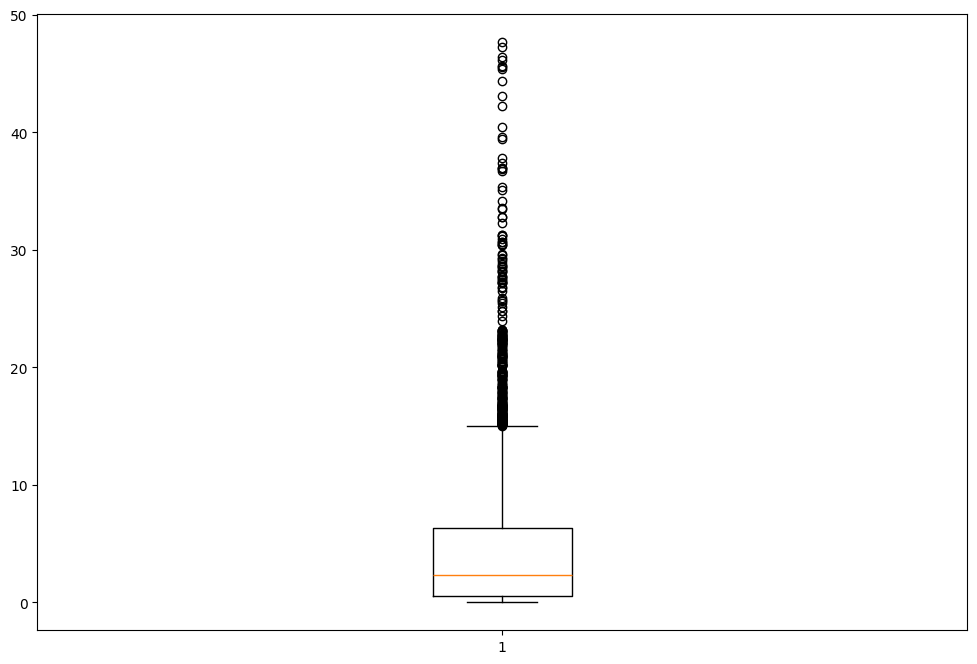

In [ ]:
plt.figure(figsize=(12,8))
plt.boxplot(dados['Metric Tons Per Capita'])
plt.show()

In [ ]:
emissao_temporal = dados.groupby('Year')['Metric Tons Per Capita'].mean()
fig = px.line(emissao_temporal.reset_index(), x = 'Year', y = 'Metric Tons Per Capita', title = 'Média de emissão anual', markers = True)
fig.show()

In [ ]:
emissao_por_pais = dados.groupby('Country')['Metric Tons Per Capita'].sum()
emissao_por_pais

,Metric Tons Per Capita
Country,
Afghanistan,3.73
Albania,37.52
Algeria,91.25
Andorra,211.66
Angola,26.94
...,...
Venezuela,158.39
Vietnam,37.47
Yemen,22.50


In [ ]:
plt.figure(figsize = (120,80))
plt.bar(height = emissao_por_pais, x = emissao_por_pais.index)
plt.title('Emissão por país')
plt.xlabel('País')
plt.ylabel('Metric Torns Per Capita')
plt.show()

In [ ]:
df_plot = dados.groupby('Year')['Emissao'].value_counts().reset_index()
df_plot

,Year,Emissao,count
0,1990,Baixa emissão,97
1,1990,Emissão elevada,40
2,1990,Emissão aceitável,20
3,1990,Emissão excessiva. Requer ação imediata!,14
4,1990,Controlar emissão,13
...,...,...,...
145,2019,Baixa emissão,89
146,2019,Emissão aceitável,36
147,2019,Emissão elevada,29
148,2019,Controlar emissão,24


In [ ]:
df_plot.columns = ['Year', 'Emissao', 'Quantidade']
df_plot

,Year,Emissao,Quantidade
0,1990,Baixa emissão,97
1,1990,Emissão elevada,40
2,1990,Emissão aceitável,20
3,1990,Emissão excessiva. Requer ação imediata!,14
4,1990,Controlar emissão,13
...,...,...,...
145,2019,Baixa emissão,89
146,2019,Emissão aceitável,36
147,2019,Emissão elevada,29
148,2019,Controlar emissão,24


In [ ]:
fig = px.line(df_plot, x = 'Year', y = 'Quantidade', color = 'Emissao', markers = True, title = 'Evolução temporal da classificação conforme emissões')
fig.update_layout(xaxis_title = 'Ano', yaxis_title = 'Quantidade de países', hovermode = 'x unified', template = 'plotly_white',width = 1200, height = 800)
fig.show()

In [ ]:
super_emissores = dados[dados['Emissao'] == 'Emissão excessiva. Requer ação imediata!']
super_emissores

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita,Emissao,Year
150,Antigua And Barbuda,Americas,01-01-2009,1390.00,16.44,Emissão excessiva. Requer ação imediata!,2009
240,Australia,Oceania,01-01-2009,395290.01,18.22,Emissão excessiva. Requer ação imediata!,2009
241,Australia,Oceania,01-01-2017,389160.00,15.82,Emissão excessiva. Requer ação imediata!,2017
242,Australia,Oceania,01-01-2008,388940.00,18.30,Emissão excessiva. Requer ação imediata!,2008
243,Australia,Oceania,01-01-2010,387540.01,17.59,Emissão excessiva. Requer ação imediata!,2010
...,...,...,...,...,...,...,...
5432,United States,Americas,01-01-1992,4879630.00,19.02,Emissão excessiva. Requer ação imediata!,1992
5433,United States,Americas,01-01-1990,4844520.00,19.41,Emissão excessiva. Requer ação imediata!,1990
5434,United States,Americas,01-01-2017,4819370.12,14.82,Emissão excessiva. Requer ação imediata!,2017
5435,United States,Americas,01-01-2019,4817720.21,14.67,Emissão excessiva. Requer ação imediata!,2019


In [ ]:
super_emissoes = dados.groupby('Country')['Metric Tons Per Capita'].sum().reset_index()
super_emissoes.columns = ['País', 'Emissão acumulada no período']
super_emissoes = super_emissoes.sort_values(by = 'Emissão acumulada no período', ascending = False)
super_emissoes

,País,Emissão acumulada no período
136,Qatar,1156.22
177,UAE,753.35
87,Kuwait,707.56
12,Bahrain,662.09
97,Luxembourg,646.79
...,...,...
99,Malawi,1.93
152,Somalia,1.90
32,Central African Republic,1.47
43,Democratic Republic Of Congo,1.31


In [ ]:
fig = px.bar(super_emissoes, y = 'País', x = 'Emissão acumulada no período', orientation = 'h', title = 'Essão de CO2 per capita por país (1990 - 2019)', text_auto = '.1f')
fig.update_layout(template = 'plotly_white', height = max(800, len(super_emissoes)*20),yaxis = dict(categoryorder = 'total ascending'))
fig.update_traces(textfont_size = 12, textposition = 'outside')
fig.show()